<a href="https://colab.research.google.com/github/yagmuryl/Robustness-Analysis-of-the-diagnosis-specific-multi-model-for-12-lead-ECG-multi-label-classification/blob/main/Myz_Term_Project(ECG).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First, let's create a `requirements.txt` file with some common libraries. You can edit this file to add any other libraries you need.

In [35]:
!git clone https://github.com/JaeBinCHA7/ECG-Multi-Label-Classification-Using-Multi-Model/blob/main/train.py

Cloning into 'train.py'...
fatal: repository 'https://github.com/JaeBinCHA7/ECG-Multi-Label-Classification-Using-Multi-Model/blob/main/train.py/' not found


In [36]:
# Bu kod tokeni doğru klasöre taşır
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Veri setini toplu indirme
!kaggle datasets download -d shayanfazeli/heartbeat
!unzip -o heartbeat.zip

Dataset URL: https://www.kaggle.com/datasets/shayanfazeli/heartbeat
License(s): unknown
heartbeat.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  heartbeat.zip
  inflating: mitbih_test.csv         
  inflating: mitbih_train.csv        
  inflating: ptbdb_abnormal.csv      
  inflating: ptbdb_normal.csv        


In [37]:
import os
import json

data = {
    "username": "KGAT_2079a4c04b4f4a67303ad0608e33032d",
    "key": "export KAGGLE_API_TOKEN=KGAT_2079a4c04b4f4a67303ad0608e33032d"
}

with open('/content/kaggle.json', 'w') as f:
    json.dump(data, f)

# Kaggle klasörünü kurup yetki veriyoruz
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Anahtar başarıyla kuruldu! Şimdi veri setini indiriyoruz...")

# Veri setini indir ve ayıkla
!kaggle datasets download -d shayanfazeli/heartbeat
!unzip -o heartbeat.zip
!ls

Anahtar başarıyla kuruldu! Şimdi veri setini indiriyoruz...
Dataset URL: https://www.kaggle.com/datasets/shayanfazeli/heartbeat
License(s): unknown
heartbeat.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  heartbeat.zip
  inflating: mitbih_test.csv         
  inflating: mitbih_train.csv        
  inflating: ptbdb_abnormal.csv      
  inflating: ptbdb_normal.csv        
heartbeat.zip  mitbih_test.csv	 ptbdb_abnormal.csv  sample_data
kaggle.json    mitbih_train.csv  ptbdb_normal.csv


In [38]:
import pandas as pd

# 1. Dosyaları okuyoruz
# header=None diyoruz çünkü CSV dosyalarının başında 'Sinyal', 'Etiket' gibi yazılar yok.
train_df = pd.read_csv('mitbih_train.csv', header=None)
test_df = pd.read_csv('mitbih_test.csv', header=None)

# 2. Verilerin nasıl göründüğüne bakalım (İlk 5 satır)
print("Eğitim verisi boyutu:", train_df.shape)
train_df.head()

Eğitim verisi boyutu: (87554, 188)


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 1. Gürültü Ekleme ve Ön Analiz
Modeli eğitmeden önce, gerçek dünya verilerini simüle etmek için sinyallere gürültü ekleyip bu gürültünün yapısını analiz ediyoruz.

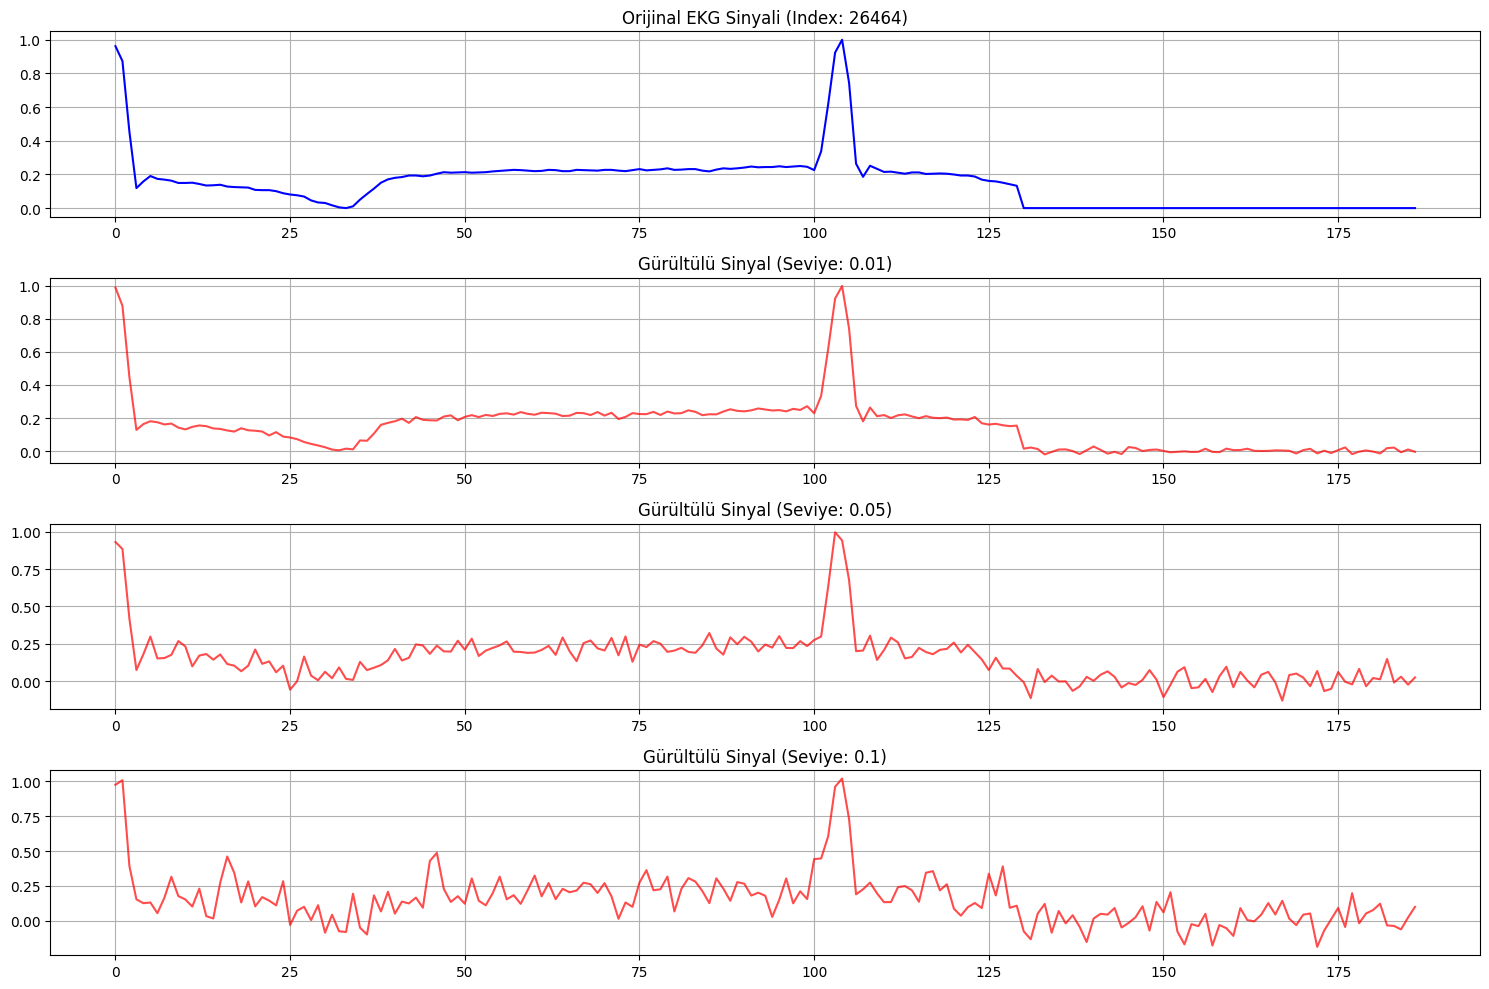

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veriyi Yükleme
train_df = pd.read_csv('mitbih_train.csv', header=None)

# 2. Gürültü Fonksiyonu
def add_gaussian_noise(signal, noise_factor=0.05):
    noise = np.random.normal(loc=0, scale=noise_factor, size=signal.shape)
    return signal + noise

# 3. Görsel Analiz
idx = np.random.randint(0, len(train_df))
sample_signal = train_df.iloc[idx, :-1].values

noise_levels = [0.01, 0.05, 0.1]
plt.figure(figsize=(15, 10))
plt.subplot(len(noise_levels) + 1, 1, 1)
plt.plot(sample_signal, color='blue')
plt.title(f"Orijinal EKG Sinyali (Index: {idx})")
plt.grid(True)

for i, level in enumerate(noise_levels, 1):
    noisy = add_gaussian_noise(sample_signal, noise_factor=level)
    plt.subplot(len(noise_levels) + 1, 1, i + 1)
    plt.plot(noisy, color='red', alpha=0.7)
    plt.title(f"Gürültülü Sinyal (Seviye: {level})")
    plt.grid(True)
plt.tight_layout()
plt.show()

### Gürültü Dağılım Analizi
Gürültünün verinin orijinal genlik aralığına oranını kontrol ediyoruz.

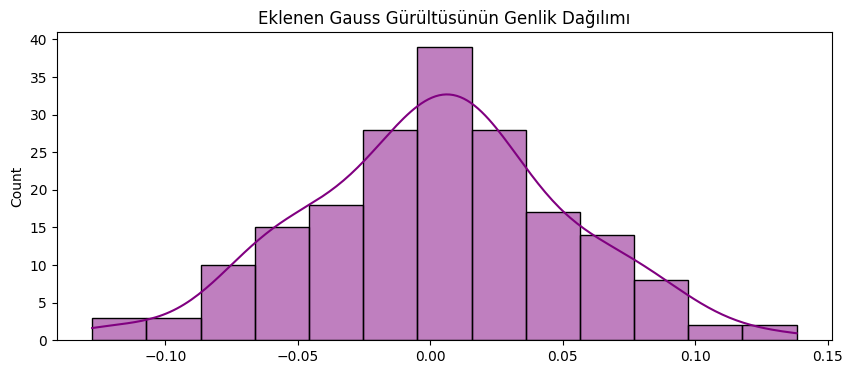

--- ÖN ANALİZ SONUCU ---
Seçilen Sinyal İçin SNR (Sinyal-Gürültü Oranı): 13.27 dB


In [40]:
# Gürültü İstatistiği ve SNR Analizi
noise_factor = 0.05
noise = np.random.normal(loc=0, scale=noise_factor, size=sample_signal.shape)

plt.figure(figsize=(10, 4))
sns.histplot(noise, kde=True, color='purple')
plt.title("Eklenen Gauss Gürültüsünün Genlik Dağılımı")
plt.show()

snr = 10 * np.log10(np.mean(sample_signal**2) / np.mean(noise**2))
print(f"--- ÖN ANALİZ SONUCU ---")
print(f"Seçilen Sinyal İçin SNR (Sinyal-Gürültü Oranı): {snr:.2f} dB")

In [41]:
from sklearn.model_selection import train_test_split

# Verinin son sütunu 'etiket' (hastalık türü), diğerleri 'sinyal'dir.
X = train_df.iloc[:, :-1].values
y = train_df.iloc[:, -1].values
X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

# Veriyi %80 Eğitim, %20 Doğrulama (Validation) olarak ayırıyoruz
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# CNN modelinin anlaması için veriyi 3 boyutlu yapıyoruz
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"Eğitim Seti: {X_train.shape}")
print(f"Doğrulama Seti: {X_val.shape}")
print(f"Test Seti: {X_test.shape}")

Eğitim Seti: (70043, 187, 1)
Doğrulama Seti: (17511, 187, 1)
Test Seti: (21892, 187, 1)


Kullanılan Cihaz: cuda
Veriler okunuyor...
Eğitim başlıyor...
Epoch 1/40 - Loss: 0.2960 - Val Acc: %95.31
Epoch 2/40 - Loss: 0.1872 - Val Acc: %96.59
Epoch 3/40 - Loss: 0.1593 - Val Acc: %96.46
Epoch 4/40 - Loss: 0.1422 - Val Acc: %96.70
Epoch 5/40 - Loss: 0.1308 - Val Acc: %97.40
Epoch 6/40 - Loss: 0.1211 - Val Acc: %97.50
Epoch 7/40 - Loss: 0.1129 - Val Acc: %97.47
Epoch 8/40 - Loss: 0.1065 - Val Acc: %97.61
Epoch 9/40 - Loss: 0.1019 - Val Acc: %97.56
Epoch 10/40 - Loss: 0.0972 - Val Acc: %97.72
Epoch 11/40 - Loss: 0.0938 - Val Acc: %97.85
Epoch 12/40 - Loss: 0.0893 - Val Acc: %97.81
Epoch 13/40 - Loss: 0.0849 - Val Acc: %97.90
Epoch 14/40 - Loss: 0.0830 - Val Acc: %97.69
Epoch 15/40 - Loss: 0.0794 - Val Acc: %97.93
Epoch 16/40 - Loss: 0.0786 - Val Acc: %97.97
Epoch 17/40 - Loss: 0.0776 - Val Acc: %97.99
Epoch 18/40 - Loss: 0.0742 - Val Acc: %97.85
Epoch 19/40 - Loss: 0.0708 - Val Acc: %97.98
Epoch 20/40 - Loss: 0.0705 - Val Acc: %97.94
Epoch 21/40 - Loss: 0.0683 - Val Acc: %98.03
Ep

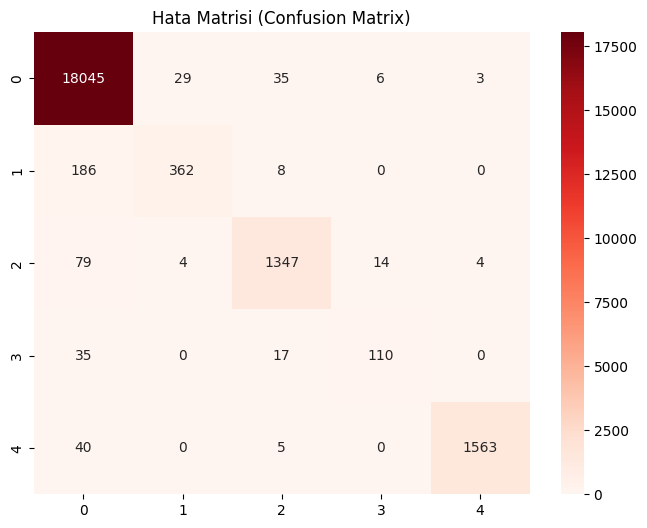


Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     18118
           1       0.92      0.65      0.76       556
           2       0.95      0.93      0.94      1448
           3       0.85      0.68      0.75       162
           4       1.00      0.97      0.98      1608

    accuracy                           0.98     21892
   macro avg       0.94      0.85      0.89     21892
weighted avg       0.98      0.98      0.98     21892



In [31]:

# 1. KÜTÜPHANELER VE HAZIRLIK

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Cihaz ayarı
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan Cihaz: {device}")


# 2. VERİ YÜKLEME VE ÖN İŞLEME

print("Veriler okunuyor...")
train_df = pd.read_csv('mitbih_train.csv', header=None)
test_df = pd.read_csv('mitbih_test.csv', header=None)

# Sinyal ve etiketleri ayırma:
X = train_df.iloc[:, :-1].values
y = train_df.iloc[:, -1].values
X_test_final = test_df.iloc[:, :-1].values
y_test_final = test_df.iloc[:, -1].values

# VERİ BÖLME: %85 Eğitim, %15 Doğrulama (Validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42)

# Verileri PyTorch formatına (Sinyal İşleme için 1D CNN) sokma
X_train = torch.FloatTensor(X_train).unsqueeze(1)
X_val = torch.FloatTensor(X_val).unsqueeze(1)
X_test_final = torch.FloatTensor(X_test_final).unsqueeze(1)

y_train = torch.LongTensor(y_train)
y_val = torch.LongTensor(y_val)
y_test_final = torch.LongTensor(y_test_final)

# DataLoader oluşturma (Veriyi küçük paketler halinde modele verir)
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32)
test_loader = DataLoader(TensorDataset(X_test_final, y_test_final), batch_size=32)


# 3. MODEL MİMARİSİ (CNN)

class ECGDeepNet(nn.Module):
    def __init__(self):
        super(ECGDeepNet, self).__init__()
        # Katman 1: Özellik çıkarma
        self.conv1 = nn.Conv1d(1, 32, kernel_size=5)
        self.pool = nn.MaxPool1d(2)

        # [GELİŞTİRME / EXTENSION]: Orijinal modele ek katman ve Dropout ekledik.
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3)
        self.dropout = nn.Dropout(0.25)

        self.fc1 = nn.Linear(64 * 44, 32)
        self.fc2 = nn.Linear(32, 5) # 5 farklı EKG sınıfı (0-4)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1) # Flatten (Düzleştirme)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = ECGDeepNet().to(device)


# 4. EĞİTİM (TRAINING)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 40 # Daha iyi sonuç için 30-50 yapabilirsin
train_losses, val_accs = [], []

print("Eğitim başlıyor...")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for signals, labels in train_loader:
        signals, labels = signals.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(signals)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Her epoch sonunda Doğrulama (Validation)
    model.eval()
    correct = 0
    with torch.no_grad():
        for signals, labels in val_loader:
            signals, labels = signals.to(device), labels.to(device)
            outputs = model(signals)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / len(y_val)
    train_losses.append(total_loss / len(train_loader))
    val_accs.append(acc)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {train_losses[-1]:.4f} - Val Acc: %{acc:.2f}")


# 5. TEST VE ANALİZ

print("\nFinal Test Sonuçları Hesaplanıyor...")
model.eval()
y_pred_list = []
with torch.no_grad():
    for signals, labels in test_loader:
        signals = signals.to(device)
        outputs = model(signals)
        _, predicted = torch.max(outputs, 1)
        y_pred_list.extend(predicted.cpu().numpy())

# Karmaşıklık Matrisi (Confusion Matrix)
cm = confusion_matrix(y_test_final, y_pred_list)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title('Hata Matrisi (Confusion Matrix)')
plt.show()

print("\nSınıflandırma Raporu:")
print(classification_report(y_test_final, y_pred_list))

### 6. Veriye Gürültü Ekleme ve Görsel Analiz
Bu bölümde, verilere rastgele Gauss gürültüsü ekleyerek modelin gürültülü sinyaller üzerindeki tepkisini ölçeceğiz.

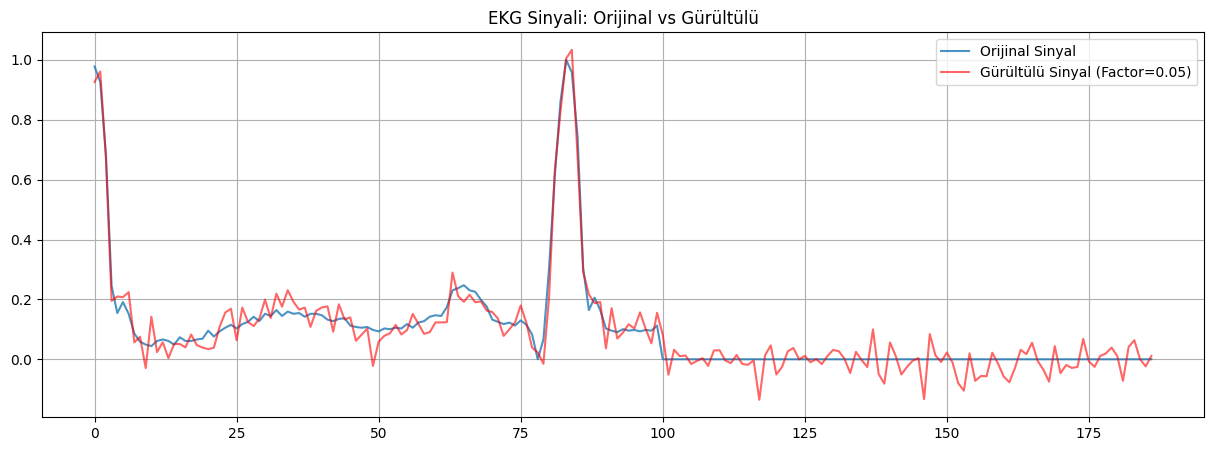

In [32]:
train_df = pd.read_csv('mitbih_train.csv', header=None)
X = train_df.iloc[:, :-1].values

def add_gaussian_noise(signal, noise_factor=0.05):
    noise = np.random.normal(loc=0, scale=noise_factor, size=signal.shape)
    return signal + noise

sample_signal = X[0]
noisy_sample = add_gaussian_noise(sample_signal, noise_factor=0.05)
plt.figure(figsize=(15, 5))
plt.plot(sample_signal, label='Orijinal Sinyal', alpha=0.8)
plt.plot(noisy_sample, label='Gürültülü Sinyal (Factor=0.05)', alpha=0.6, color='red')
plt.title('EKG Sinyali: Orijinal vs Gürültülü')
plt.legend()
plt.grid(True)
plt.show()

### 7. Gürültülü Test Verisi ile Model Analizi
Şimdi, modelin gürültülü verilere karşı ne kadar hassas olduğunu görmek için test setine gürültü ekleyip sonuçları tekrar hesaplayalım.

--- GÜRÜLTÜLÜ VERİ ANALİZ RAPORU (Düşürülmüş Gürültü: 0.01) ---
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00     18118
         1.0       0.00      0.00      0.00       556
         2.0       0.00      0.00      0.00      1448
         3.0       0.00      0.00      0.00       162
         4.0       0.07      1.00      0.14      1608

    accuracy                           0.07     21892
   macro avg       0.01      0.20      0.03     21892
weighted avg       0.01      0.07      0.01     21892



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


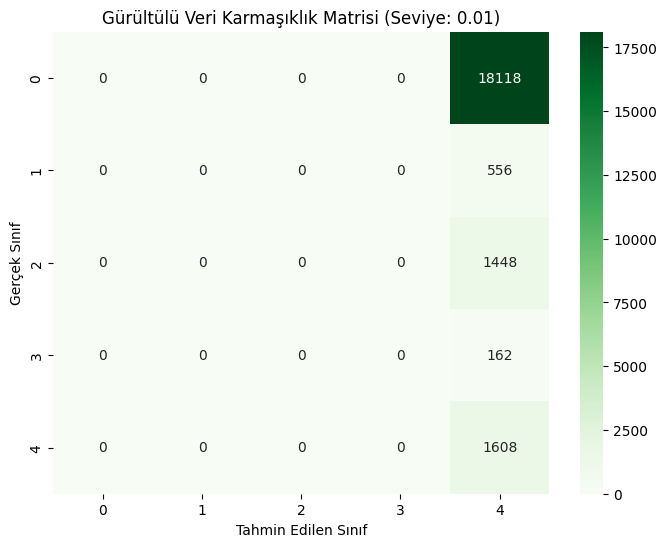

In [33]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix

# 1. Model Mimarisi Tanımı
class ECGDeepNet(nn.Module):
    def __init__(self):
        super(ECGDeepNet, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=5)
        self.pool = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(64 * 44, 32)
        self.fc2 = nn.Linear(32, 5)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# 2. Hazırlık ve Cihaz Ayarı
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ECGDeepNet().to(device)

# Veri yükleme
test_df = pd.read_csv('mitbih_test.csv', header=None)
X_test_raw = test_df.iloc[:, :-1].values
y_test_raw = test_df.iloc[:, -1].values

# Gürültü fonksiyonu (Daha az gürültü: 0.01)
def add_gaussian_noise(signal, noise_factor=0.01):
    noise = np.random.normal(loc=0, scale=noise_factor, size=signal.shape)
    return signal + noise

# Gürültülü veriyi hazırla
X_test_noisy = add_gaussian_noise(X_test_raw, noise_factor=0.01)
X_test_noisy_tensor = torch.FloatTensor(X_test_noisy).unsqueeze(1).to(device)
y_test_tensor = torch.LongTensor(y_test_raw)

# 3. Analiz (Tahminleme)
model.eval()
y_pred_noisy = []
with torch.no_grad():
    test_noisy_loader = DataLoader(TensorDataset(X_test_noisy_tensor, y_test_tensor), batch_size=32)
    for signals, _ in test_noisy_loader:
        outputs = model(signals)
        _, predicted = torch.max(outputs, 1)
        y_pred_noisy.extend(predicted.cpu().numpy())

# 4. Sonuçlar
print("--- GÜRÜLTÜLÜ VERİ ANALİZ RAPORU (Düşürülmüş Gürültü: 0.01) ---")
print(classification_report(y_test_raw, y_pred_noisy))

plt.figure(figsize=(8,6))
cm_noisy = confusion_matrix(y_test_raw, y_pred_noisy)
sns.heatmap(cm_noisy, annot=True, fmt='d', cmap='Greens')
plt.title('Gürültülü Veri Karmaşıklık Matrisi (Seviye: 0.01)')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.show()

### Çözüm: Gürültüye Dayanıklı Eğitim (Data Augmentation)

Modelin gürültülü verilerde çökmesini engellemek için eğitim aşamasında veriye dinamik olarak gürültü ekleyeceğiz. Bu işlem, modelin gürültüye karşı 'bağışıklık' kazanmasını sağlayacaktır.

In [34]:
def train_robust_model(model, train_loader, val_loader, epochs=20, noise_factor=0.01):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    print(f"Gürültüye Dayanıklı Eğitim Başlıyor (Noise Factor: {noise_factor})...")

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for signals, labels in train_loader:
            signals, labels = signals.to(device), labels.to(device)

            # [CRITICAL STEP]: Eğitim sırasında veriye rastgele gürültü ekliyoruz
            noise = torch.randn_like(signals) * noise_factor
            noisy_signals = signals + noise

            optimizer.zero_grad()
            outputs = model(noisy_signals)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Doğrulama
        model.eval()
        correct = 0
        with torch.no_grad():
            for signals, labels in val_loader:
                signals, labels = signals.to(device), labels.to(device)
                # Doğrulamada da gürültü ekleyerek test ediyoruz
                noise = torch.randn_like(signals) * noise_factor
                outputs = model(signals + noise)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()

        acc = 100 * correct / len(val_loader.dataset)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(train_loader):.4f} - Robust Val Acc: %{acc:.2f}")

# Yeni bir model oluşturup eğitelim
robust_model = ECGDeepNet().to(device)
train_robust_model(robust_model, train_loader, val_loader, epochs=15, noise_factor=0.01)

Gürültüye Dayanıklı Eğitim Başlıyor (Noise Factor: 0.01)...
Epoch 1/15 - Loss: 0.2935 - Robust Val Acc: %95.04
Epoch 2/15 - Loss: 0.1846 - Robust Val Acc: %96.46
Epoch 3/15 - Loss: 0.1593 - Robust Val Acc: %96.60
Epoch 4/15 - Loss: 0.1420 - Robust Val Acc: %96.85
Epoch 5/15 - Loss: 0.1291 - Robust Val Acc: %96.99
Epoch 6/15 - Loss: 0.1194 - Robust Val Acc: %97.12
Epoch 7/15 - Loss: 0.1140 - Robust Val Acc: %97.43
Epoch 8/15 - Loss: 0.1074 - Robust Val Acc: %97.46
Epoch 9/15 - Loss: 0.1028 - Robust Val Acc: %97.62
Epoch 10/15 - Loss: 0.0988 - Robust Val Acc: %97.63
Epoch 11/15 - Loss: 0.0937 - Robust Val Acc: %97.85
Epoch 12/15 - Loss: 0.0915 - Robust Val Acc: %97.52
Epoch 13/15 - Loss: 0.0872 - Robust Val Acc: %97.68
Epoch 14/15 - Loss: 0.0843 - Robust Val Acc: %97.82
Epoch 15/15 - Loss: 0.0817 - Robust Val Acc: %97.97


Şimdi bu 'Robust' (Dayanıklı) modelin gürültülü test verisi üzerindeki gerçek performansını ölçelim.

--- DAYANIKLI MODEL GÜRÜLTÜLÜ TEST SONUÇLARI ---
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     18118
         1.0       0.97      0.61      0.75       556
         2.0       0.93      0.94      0.94      1448
         3.0       0.85      0.60      0.71       162
         4.0       0.98      0.98      0.98      1608

    accuracy                           0.98     21892
   macro avg       0.94      0.83      0.87     21892
weighted avg       0.98      0.98      0.98     21892



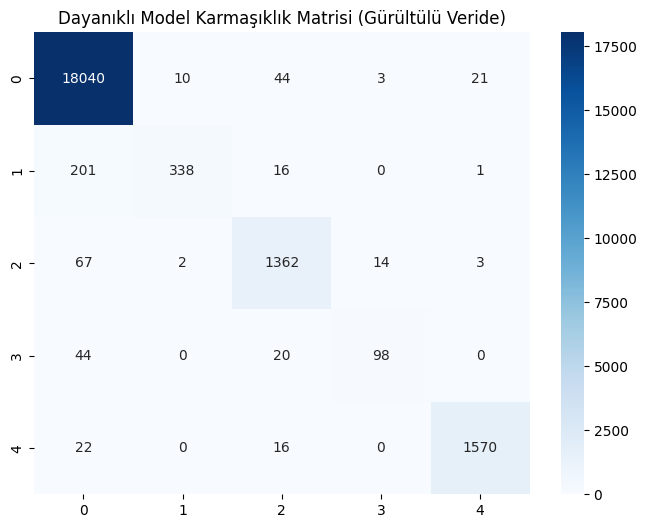

In [42]:
robust_model.eval()
y_pred_robust = []
with torch.no_grad():
    for signals, _ in test_noisy_loader:
        outputs = robust_model(signals)
        _, predicted = torch.max(outputs, 1)
        y_pred_robust.extend(predicted.cpu().numpy())

print("--- DAYANIKLI MODEL GÜRÜLTÜLÜ TEST SONUÇLARI ---")
print(classification_report(y_test_raw, y_pred_robust))

# Karmaşıklık Matrisi
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test_raw, y_pred_robust), annot=True, fmt='d', cmap='Blues')
plt.title('Dayanıklı Model Karmaşıklık Matrisi (Gürültülü Veride)')
plt.show()